
[INFO] Memproses Indonesia (Format .npy murni)...
  -> SUKSES! 500 matriks.

[INFO] Memproses STEAD Global dari Extreme SSD...
  -> SUKSES! 500 matriks.

[INFO] Memproses UUSS (Isolasi Data Tak Terdaftar)...
  -> Ditemukan 0 ID tak terdaftar di CSV (Asumsi: murni Noise).
  -> SUKSES! 0 matriks.

[INFO] Mengkalkulasi Power Spectral Density (Metode Welch)...

[INFO] Merender Grafik Komparasi Forensik...


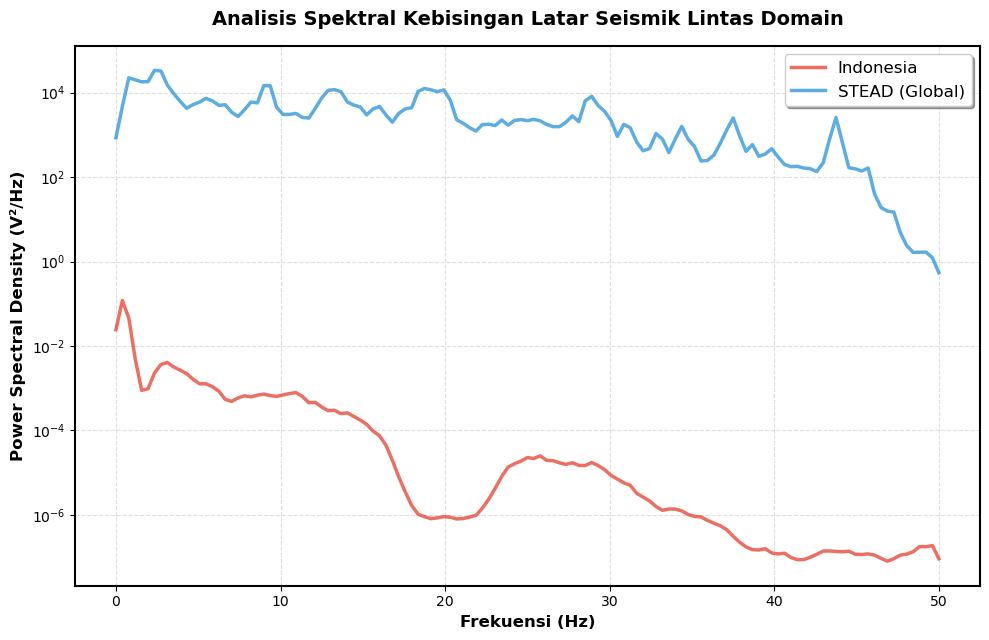


[SELESAI] Grafik bukti empiris 3-Domain berhasil ditampilkan di layar.


In [5]:
# -*- coding: utf-8 -*-
import os
import glob
import json
import h5py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

# ==============================================================================
# PATH SUMBER DATA LINTAS DOMAIN
# ==============================================================================
DIR_NOISE_INDO = r"/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/indonesia_waveform_master_data/output_data_npypure_3c_noise_9s"

PATH_STEAD_CSV = '/Volumes/Extreme SSD/stream_stead/data_stead/merge.csv'
PATH_STEAD_HDF5 = '/Volumes/Extreme SSD/stream_stead/data_stead/merge.hdf5'

PATH_UUSS_JSON = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Benchmark_ UUSS 3C_ test n2222 r100/UUSS 3C data, test n2222 r100.json'
PATH_UUSS_META = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Benchmark_ UUSS 3C_ test n2222 r100/UUSS 3C meta, test snr_db, n2222.csv'

N_SAMPLES = 500  
FS = 100         

if __name__ == "__main__":
    noise_collection = {}

    # 1. EKSTRAKSI INDONESIA (.npy)
    print("\n[INFO] Memproses Indonesia (Format .npy murni)...")
    npy_files = glob.glob(os.path.join(DIR_NOISE_INDO, "*.npy"))
    np.random.seed(42)
    selected_npy = np.random.choice(npy_files, min(N_SAMPLES, len(npy_files)), replace=False)
    noise_collection['Indonesia'] = np.array([np.load(f)[:700] for f in selected_npy])
    print(f"  -> SUKSES! {len(noise_collection['Indonesia'])} matriks.")

    # 2. EKSTRAKSI STEAD DARI EXTREME SSD
    print("\n[INFO] Memproses STEAD Global dari Extreme SSD...")
    df_stead = pd.read_csv(PATH_STEAD_CSV, low_memory=False)
    df_stead_noise = df_stead[df_stead['trace_category'] == 'noise'].sample(n=N_SAMPLES, random_state=42)
    stead_traces = df_stead_noise['trace_name'].astype(str).values
    
    stead_waves = []
    with h5py.File(PATH_STEAD_HDF5, 'r') as f_h5:
        for trace in stead_traces:
            if trace in f_h5['data']:
                stead_waves.append(f_h5['data'][trace][()][:700])
    noise_collection['STEAD (Global)'] = np.array(stead_waves)
    print(f"  -> SUKSES! {len(stead_waves)} matriks.")
    del df_stead, df_stead_noise

    # 3. EKSTRAKSI UUSS (MENGGUNAKAN LOGIKA "UNLISTED IDs")
    print("\n[INFO] Memproses UUSS (Isolasi Data Tak Terdaftar)...")
    df_uuss = pd.read_csv(PATH_UUSS_META, header=None)
    gempa_ids = set(df_uuss[0].astype(str).str.strip().tolist())
    
    with open(PATH_UUSS_JSON, 'r') as f:
        uuss_data = json.load(f)
    
    noise_keys = [k for k in uuss_data.keys() if str(k).strip() not in gempa_ids]
    print(f"  -> Ditemukan {len(noise_keys)} ID tak terdaftar di CSV (Asumsi: murni Noise).")
    
    np.random.seed(42)
    selected_uuss_keys = np.random.choice(noise_keys, min(N_SAMPLES, len(noise_keys)), replace=False)
    
    uuss_waves = [np.array(uuss_data[k])[:700] for k in selected_uuss_keys]
    noise_collection['UUSS (Utah, Latih Asli)'] = np.array(uuss_waves)
    print(f"  -> SUKSES! {len(uuss_waves)} matriks.")

    # ==========================================================================
    # KALKULASI PSD & VISUALISASI
    # ==========================================================================
    print("\n[INFO] Mengkalkulasi Power Spectral Density (Metode Welch)...")
    psd_results = {}
    
    for domain, waves in noise_collection.items():
        if waves is None or len(waves) == 0: continue
        all_psd = []
        for wave in waves:
            z_component = wave[:, -1] if len(wave.shape) > 1 and wave.shape[-1] == 3 else wave.flatten()
            z_component = z_component - np.mean(z_component)
            freqs, psd = welch(z_component, fs=FS, nperseg=256)
            all_psd.append(psd)
        psd_results[domain] = (freqs, np.mean(all_psd, axis=0))

    print("\n[INFO] Merender Grafik Komparasi Forensik...")
    plt.figure(figsize=(10, 6.5))
    colors = {'Indonesia': '#e74c3c', 'STEAD (Global)': '#3498db', 'UUSS (Utah, Latih Asli)': '#2ecc71'}
    
    for domain, (freqs, mean_psd) in psd_results.items():
        plt.semilogy(freqs, mean_psd, label=domain, color=colors.get(domain, 'black'), linewidth=2.5, alpha=0.8)

    plt.title("Analisis Spektral Kebisingan Latar Seismik Lintas Domain", fontsize=14, weight='bold', pad=15)
    plt.xlabel("Frekuensi (Hz)", fontsize=12, weight='bold')
    plt.ylabel("Power Spectral Density (V²/Hz)", fontsize=12, weight='bold')
    plt.grid(True, which="both", ls="--", alpha=0.4)
    plt.legend(fontsize=12, frameon=True, shadow=True)
    
    ax = plt.gca()
    for spine in ax.spines.values(): spine.set_linewidth(1.5)
        
    plt.tight_layout()
    
    # MENAMPILKAN GRAFIK LANGSUNG KE LAYAR
    plt.show()
    print("\n[SELESAI] Grafik bukti empiris 3-Domain berhasil ditampilkan di layar.")

In [6]:
# -*- coding: utf-8 -*-
import json
import pandas as pd
import numpy as np

# Path absolut ke file
PATH_JSON = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Benchmark_ STEAD 3C_ test n15275 r100/STEAD data, test n15275 r100.json'
PATH_CSV = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Benchmark_ STEAD 3C_ test n15275 r100/STEAD 3C meta, test SNR_DB, n15275.csv'

if __name__ == "__main__":
    print("="*60)
    print(" 🕵️ PEMBEDAHAN FILE JSON (DATA GELOMBANG)")
    print("="*60)
    try:
        with open(PATH_JSON, 'r') as f:
            stead_json = json.load(f)
            
        total_keys = len(stead_json.keys())
        print(f"[INFO] Total Trace ID di dalam JSON : {total_keys} matriks")
        
        # Mengintip 1 sampel data pertama
        first_key = list(stead_json.keys())[0]
        first_matrix = np.array(stead_json[first_key])
        print(f"[INFO] Contoh Trace ID (Kunci)      : {first_key}")
        print(f"[INFO] Bentuk Matriks (Shape)       : {first_matrix.shape}")
        print(f"[INFO] Tipe Data dalam Matriks      : {first_matrix.dtype}")
    except Exception as e:
        print(f"[ERROR] Gagal membedah JSON: {e}")

    print("\n" + "="*60)
    print(" 📊 PEMBEDAHAN FILE CSV (METADATA & LABEL)")
    print("="*60)
    try:
        df_meta = pd.read_csv(PATH_CSV)
        
        print(f"[INFO] Total Baris Data di CSV      : {len(df_meta)} baris")
        print(f"[INFO] Total Kolom (Atribut)        : {len(df_meta.columns)} kolom\n")
        
        print(" DAFTAR LENGKAP KOLOM:")
        for i, col in enumerate(df_meta.columns):
            print(f"  {i+1}. {col}")
            
        print("\n" + "-"*60)
        # Analisis khusus pada kolom label utama
        label_col = 'trace_category'
        if label_col in df_meta.columns:
            print(f" RINCIAN LABEL PADA KOLOM '{label_col}':")
            label_counts = df_meta[label_col].value_counts()
            for label, count in label_counts.items():
                print(f"  -> '{label}': {count} sampel")
        else:
            print(f" [WARNING] Kolom '{label_col}' tidak ditemukan.")
            
    except Exception as e:
        print(f"[ERROR] Gagal membedah CSV: {e}")
    print("="*60)

 🕵️ PEMBEDAHAN FILE JSON (DATA GELOMBANG)
[INFO] Total Trace ID di dalam JSON : 15275 matriks
[INFO] Contoh Trace ID (Kunci)      : 1127269
[INFO] Bentuk Matriks (Shape)       : ()
[INFO] Tipe Data dalam Matriks      : object

 📊 PEMBEDAHAN FILE CSV (METADATA & LABEL)
[INFO] Total Baris Data di CSV      : 15275 baris
[INFO] Total Kolom (Atribut)        : 37 kolom

 DAFTAR LENGKAP KOLOM:
  1. index_o
  2. network_code
  3. receiver_code
  4. receiver_type
  5. receiver_latitude
  6. receiver_longitude
  7. receiver_elevation_m
  8. p_arrival_sample
  9. p_status
  10. p_weight
  11. p_travel_sec
  12. s_arrival_sample
  13. s_status
  14. s_weight
  15. source_id
  16. source_origin_time
  17. source_origin_uncertainty_sec
  18. source_latitude
  19. source_longitude
  20. source_error_sec
  21. source_gap_deg
  22. source_horizontal_uncertainty_km
  23. source_depth_km
  24. source_depth_uncertainty_km
  25. source_magnitude
  26. source_magnitude_type
  27. source_magnitude_author
  2


[INFO] Mengekstraksi Ambient Noise Indonesia...
[INFO] Mengekstraksi Ambient Noise STEAD Global...
[INFO] Mengekstraksi Pre-Event Noise UUSS (Zhi Geng Baseline)...
[INFO] Mengekstraksi Pre-Event Noise STEAD (Zhi Geng Baseline)...

[INFO] Mengkalkulasi Power Spectral Density (Welch)...
[INFO] Merender Grafik Investigasi Final...


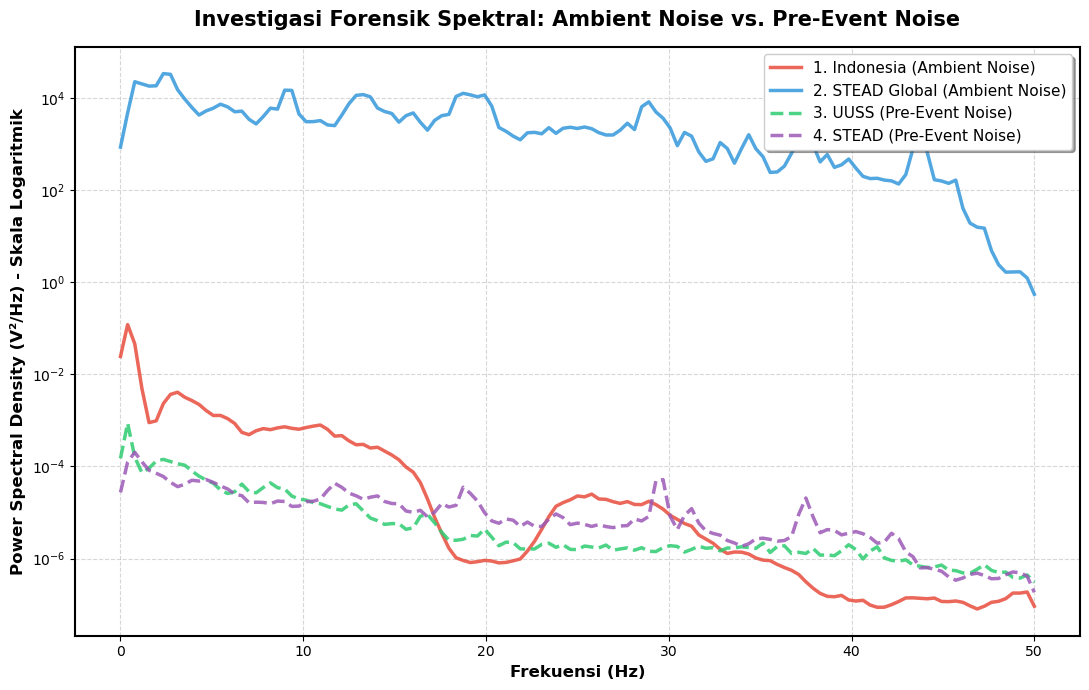


[SELESAI] Grafik investigasi final berhasil ditampilkan di layar.


In [7]:
# -*- coding: utf-8 -*-
import os
import glob
import json
import h5py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

# ==============================================================================
# PATH SUMBER DATA LINTAS DOMAIN
# ==============================================================================
# 1. Ambient Noise Murni
DIR_NOISE_INDO = r"/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/indonesia_waveform_master_data/output_data_npypure_3c_noise_9s"
PATH_STEAD_CSV = '/Volumes/Extreme SSD/stream_stead/data_stead/merge.csv'
PATH_STEAD_HDF5 = '/Volumes/Extreme SSD/stream_stead/data_stead/merge.hdf5'

# 2. Pre-Event Noise (Dari JSON Evaluasi Baseline)
PATH_UUSS_JSON = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Benchmark_ UUSS 3C_ test n2222 r100/UUSS 3C data, test n2222 r100.json'
PATH_STEAD_BENCH_JSON = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Benchmark_ STEAD 3C_ test n15275 r100/STEAD data, test n15275 r100.json'

N_SAMPLES = 500  
FS = 100         

if __name__ == "__main__":
    noise_collection = {}

    # --------------------------------------------------------------------------
    # 1. EKSTRAKSI AMBIENT NOISE MURNI (Stress Test Bapak)
    # --------------------------------------------------------------------------
    print("\n[INFO] Mengekstraksi Ambient Noise Indonesia...")
    npy_files = glob.glob(os.path.join(DIR_NOISE_INDO, "*.npy"))
    np.random.seed(42)
    selected_npy = np.random.choice(npy_files, min(N_SAMPLES, len(npy_files)), replace=False)
    noise_collection['1. Indonesia (Ambient Noise)'] = np.array([np.load(f)[:700, -1] for f in selected_npy])

    print("[INFO] Mengekstraksi Ambient Noise STEAD Global...")
    df_stead = pd.read_csv(PATH_STEAD_CSV, low_memory=False)
    df_stead_noise = df_stead[df_stead['trace_category'] == 'noise'].sample(n=N_SAMPLES, random_state=42)
    stead_traces = df_stead_noise['trace_name'].astype(str).values
    
    stead_ambient = []
    with h5py.File(PATH_STEAD_HDF5, 'r') as f_h5:
        for trace in stead_traces:
            if trace in f_h5['data']:
                stead_ambient.append(f_h5['data'][trace][()][:700, -1])
    noise_collection['2. STEAD Global (Ambient Noise)'] = np.array(stead_ambient)
    del df_stead, df_stead_noise

    # --------------------------------------------------------------------------
    # 2. EKSTRAKSI PRE-EVENT NOISE (Cara Evaluasi Zhi Geng)
    # --------------------------------------------------------------------------
    print("[INFO] Mengekstraksi Pre-Event Noise UUSS (Zhi Geng Baseline)...")
    with open(PATH_UUSS_JSON, 'r') as f:
        uuss_data = json.load(f)
    
    uuss_keys = list(uuss_data.keys())
    np.random.seed(42)
    sel_uuss_keys = np.random.choice(uuss_keys, min(N_SAMPLES, len(uuss_keys)), replace=False)
    
    # Ambil kunci "Z_noise" dan pastikan panjangnya 700
    uuss_pre_noise = [np.array(uuss_data[k]["Z_noise"])[-700:] for k in sel_uuss_keys if "Z_noise" in uuss_data[k]]
    noise_collection['3. UUSS (Pre-Event Noise)'] = np.array(uuss_pre_noise)

    print("[INFO] Mengekstraksi Pre-Event Noise STEAD (Zhi Geng Baseline)...")
    with open(PATH_STEAD_BENCH_JSON, 'r') as f:
        stead_bench_data = json.load(f)
        
    stead_bench_keys = list(stead_bench_data.keys())
    np.random.seed(42)
    sel_stead_bench = np.random.choice(stead_bench_keys, min(N_SAMPLES, len(stead_bench_keys)), replace=False)
    
    stead_pre_noise = [np.array(stead_bench_data[k]["Z_noise"])[-700:] for k in sel_stead_bench if "Z_noise" in stead_bench_data[k]]
    noise_collection['4. STEAD (Pre-Event Noise)'] = np.array(stead_pre_noise)

    # --------------------------------------------------------------------------
    # 3. KALKULASI PSD & VISUALISASI LENGKAP
    # --------------------------------------------------------------------------
    print("\n[INFO] Mengkalkulasi Power Spectral Density (Welch)...")
    psd_results = {}
    
    for domain, waves in noise_collection.items():
        if waves is None or len(waves) == 0: continue
        all_psd = []
        for wave in waves:
            # Sinyal sudah diekstrak komponen Z saja
            wave = wave - np.mean(wave) # Detrending
            freqs, psd = welch(wave, fs=FS, nperseg=256)
            all_psd.append(psd)
        psd_results[domain] = (freqs, np.mean(all_psd, axis=0))

    print("[INFO] Merender Grafik Investigasi Final...")
    plt.figure(figsize=(11, 7))
    
    colors = {
        '1. Indonesia (Ambient Noise)': '#e74c3c',       # Merah 
        '2. STEAD Global (Ambient Noise)': '#3498db',    # Biru
        '3. UUSS (Pre-Event Noise)': '#2ecc71',          # Hijau
        '4. STEAD (Pre-Event Noise)': '#9b59b6'          # Ungu
    }
    
    linestyles = {
        '1. Indonesia (Ambient Noise)': '-',       
        '2. STEAD Global (Ambient Noise)': '-',    
        '3. UUSS (Pre-Event Noise)': '--',          # Garis putus-putus untuk Pre-Event
        '4. STEAD (Pre-Event Noise)': '--'          
    }
    
    for domain, (freqs, mean_psd) in sorted(psd_results.items()):
        plt.semilogy(freqs, mean_psd, label=domain, 
                     color=colors.get(domain, 'black'), 
                     linestyle=linestyles.get(domain, '-'),
                     linewidth=2.5, alpha=0.85)

    plt.title("Investigasi Forensik Spektral: Ambient Noise vs. Pre-Event Noise", fontsize=15, weight='bold', pad=15)
    plt.xlabel("Frekuensi (Hz)", fontsize=12, weight='bold')
    plt.ylabel("Power Spectral Density (V²/Hz) - Skala Logaritmik", fontsize=12, weight='bold')
    plt.grid(True, which="both", ls="--", alpha=0.5)
    plt.legend(fontsize=11, frameon=True, shadow=True, loc='upper right')
    
    ax = plt.gca()
    for spine in ax.spines.values(): spine.set_linewidth(1.5)
        
    plt.tight_layout()
    plt.show()
    print("\n[SELESAI] Grafik investigasi final berhasil ditampilkan di layar.")


[INFO] Mengekstraksi Ambient Noise Indonesia...
[INFO] Mengekstraksi Ambient Noise STEAD Global...
[INFO] Mengekstraksi Pre-Event Noise UUSS (Zhi Geng Baseline)...
[INFO] Mengekstraksi Pre-Event Noise STEAD (Zhi Geng Baseline)...

[INFO] MENERAPKAN MAX-ABSOLUTE NORMALIZATION (Standar Zhi Geng)...
[INFO] Mengkalkulasi Power Spectral Density (Welch)...
[INFO] Merender Grafik Bukti Paradoks Normalisasi...


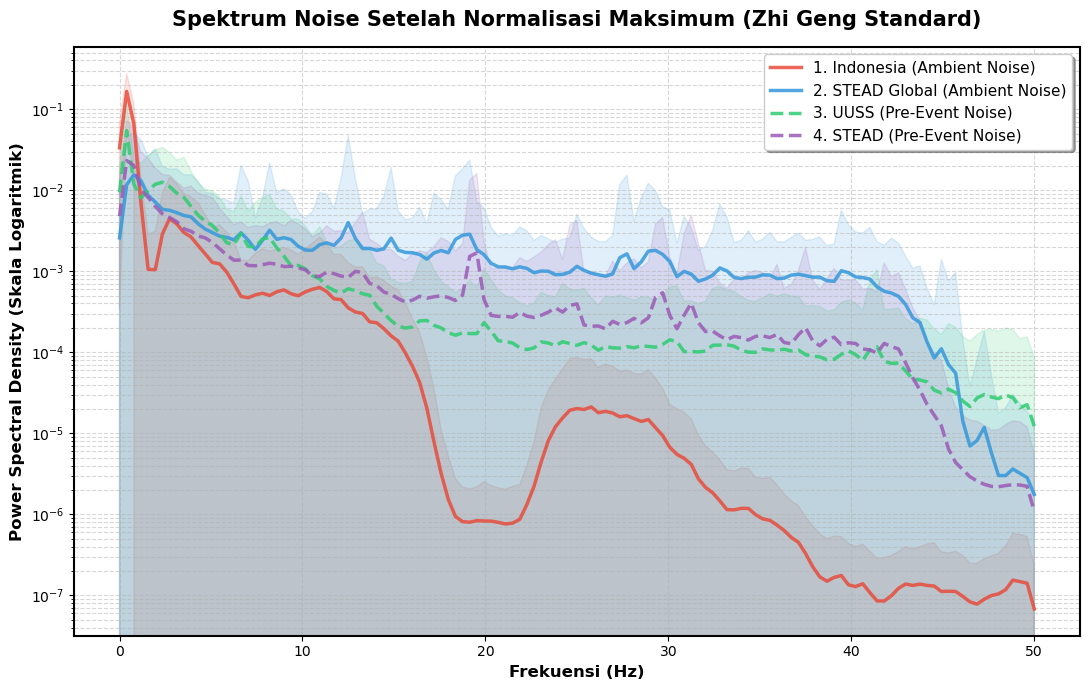


[SELESAI] Grafik efek normalisasi berhasil ditampilkan di layar.


In [19]:
# -*- coding: utf-8 -*-
import os
import glob
import json
import h5py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

# ==============================================================================
# PATH SUMBER DATA LINTAS DOMAIN
# ==============================================================================
DIR_NOISE_INDO = r"/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/indonesia_waveform_master_data/output_data_npypure_3c_noise_9s"
PATH_STEAD_CSV = '/Volumes/Extreme SSD/stream_stead/data_stead/merge.csv'
PATH_STEAD_HDF5 = '/Volumes/Extreme SSD/stream_stead/data_stead/merge.hdf5'

PATH_UUSS_JSON = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Benchmark_ UUSS 3C_ test n2222 r100/UUSS 3C data, test n2222 r100.json'
PATH_STEAD_BENCH_JSON = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Benchmark_ STEAD 3C_ test n15275 r100/STEAD data, test n15275 r100.json'

N_SAMPLES = 500  
FS = 100         

# ==============================================================================
# FUNGSI PRAPEMROSESAN STANDAR ZHI GENG (BASELINE)
# ==============================================================================
def zhi_geng_standard_preprocessing(wave):
    """
    Meniru 100% perlakuan model baseline terhadap sinyal:
    1. Detrending (dikurangi mean)
    2. Max-Absolute Normalization (puncak ditarik ke 1.0)
    """
    wave = wave - np.mean(wave) # Detrending
    max_val = np.max(np.abs(wave))
    if max_val > 0:
        wave = wave / max_val   # Normalisasi ekstrem
    return wave

if __name__ == "__main__":
    noise_collection = {}

    # 1. EKSTRAKSI AMBIENT NOISE MURNI
    print("\n[INFO] Mengekstraksi Ambient Noise Indonesia...")
    npy_files = glob.glob(os.path.join(DIR_NOISE_INDO, "*.npy"))
    np.random.seed(42)
    selected_npy = np.random.choice(npy_files, min(N_SAMPLES, len(npy_files)), replace=False)
    noise_collection['1. Indonesia (Ambient Noise)'] = np.array([np.load(f)[:700, -1] for f in selected_npy])

    print("[INFO] Mengekstraksi Ambient Noise STEAD Global...")
    df_stead = pd.read_csv(PATH_STEAD_CSV, low_memory=False)
    df_stead_noise = df_stead[df_stead['trace_category'] == 'noise'].sample(n=N_SAMPLES, random_state=42)
    stead_traces = df_stead_noise['trace_name'].astype(str).values
    
    stead_ambient = []
    with h5py.File(PATH_STEAD_HDF5, 'r') as f_h5:
        for trace in stead_traces:
            if trace in f_h5['data']:
                stead_ambient.append(f_h5['data'][trace][()][:700, -1])
    noise_collection['2. STEAD Global (Ambient Noise)'] = np.array(stead_ambient)
    del df_stead, df_stead_noise

    # 2. EKSTRAKSI PRE-EVENT NOISE
    print("[INFO] Mengekstraksi Pre-Event Noise UUSS (Zhi Geng Baseline)...")
    with open(PATH_UUSS_JSON, 'r') as f: uuss_data = json.load(f)
    uuss_keys = list(uuss_data.keys())
    np.random.seed(42)
    sel_uuss_keys = np.random.choice(uuss_keys, min(N_SAMPLES, len(uuss_keys)), replace=False)
    noise_collection['3. UUSS (Pre-Event Noise)'] = np.array([np.array(uuss_data[k]["Z_noise"])[-700:] for k in sel_uuss_keys if "Z_noise" in uuss_data[k]])

    print("[INFO] Mengekstraksi Pre-Event Noise STEAD (Zhi Geng Baseline)...")
    with open(PATH_STEAD_BENCH_JSON, 'r') as f: stead_bench_data = json.load(f)
    stead_bench_keys = list(stead_bench_data.keys())
    np.random.seed(42)
    sel_stead_bench = np.random.choice(stead_bench_keys, min(N_SAMPLES, len(stead_bench_keys)), replace=False)
    noise_collection['4. STEAD (Pre-Event Noise)'] = np.array([np.array(stead_bench_data[k]["Z_noise"])[-700:] for k in sel_stead_bench if "Z_noise" in stead_bench_data[k]])

    # 3. IMPLEMENTASI STANDAR ZHI GENG & KALKULASI PSD
    print("\n[INFO] MENERAPKAN MAX-ABSOLUTE NORMALIZATION (Standar Zhi Geng)...")
    print("[INFO] Mengkalkulasi Power Spectral Density (Welch)...")
    psd_results = {}
    
    for domain, waves in noise_collection.items():
        if waves is None or len(waves) == 0: continue
        # Ubah bagian loop ini
        all_psd = []
        for wave in waves:
            processed_wave = zhi_geng_standard_preprocessing(wave)
            freqs, psd = welch(processed_wave, fs=FS, nperseg=256)
            all_psd.append(psd)
        
        # Tambahkan perhitungan standar deviasi
        mean_psd = np.mean(all_psd, axis=0)
        std_psd = np.std(all_psd, axis=0) # <--- TAMBAHKAN INI
        psd_results[domain] = (freqs, mean_psd, std_psd) # Simpan std-nya

    # 4. VISUALISASI
    print("[INFO] Merender Grafik Bukti Paradoks Normalisasi...")
    plt.figure(figsize=(11, 7))
    
    colors = {'1. Indonesia (Ambient Noise)': '#e74c3c', '2. STEAD Global (Ambient Noise)': '#3498db', 
              '3. UUSS (Pre-Event Noise)': '#2ecc71', '4. STEAD (Pre-Event Noise)': '#9b59b6'}
    linestyles = {'1. Indonesia (Ambient Noise)': '-', '2. STEAD Global (Ambient Noise)': '-', 
                  '3. UUSS (Pre-Event Noise)': '--', '4. STEAD (Pre-Event Noise)': '--'}
    
    # Saat plotting, gunakan fill_between untuk shading
    for domain, (freqs, mean_psd, std_psd) in sorted(psd_results.items()):
        plt.semilogy(freqs, mean_psd, label=domain, color=colors.get(domain, 'black'), 
                     linestyle=linestyles.get(domain, '-'), linewidth=2.5, alpha=0.85)
        # Tambahkan shading untuk varians
        plt.fill_between(freqs, mean_psd - std_psd, mean_psd + std_psd, alpha=0.15, color=colors.get(domain, 'black'))

    plt.title("Spektrum Noise Setelah Normalisasi Maksimum (Zhi Geng Standard)", fontsize=15, weight='bold', pad=15)
    plt.xlabel("Frekuensi (Hz)", fontsize=12, weight='bold')
    plt.ylabel("Power Spectral Density (Skala Logaritmik)", fontsize=12, weight='bold')
    plt.grid(True, which="both", ls="--", alpha=0.5)
    plt.legend(fontsize=11, frameon=True, shadow=True, loc='upper right')
    
    ax = plt.gca()
    for spine in ax.spines.values(): spine.set_linewidth(1.5)
        
    plt.tight_layout()
    plt.show()
    print("\n[SELESAI] Grafik efek normalisasi berhasil ditampilkan di layar.")

[INFO] Mengumpulkan data 3-Domain...
[INFO] Mengekstraksi fitur laten...
[INFO] Running UMAP Analysis...


/opt/homebrew/Caskroom/miniforge/base/envs/mcu_quake_env/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[INFO] Plot tersimpan di: /Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/figures_disertasi/latent_space_divergence.png


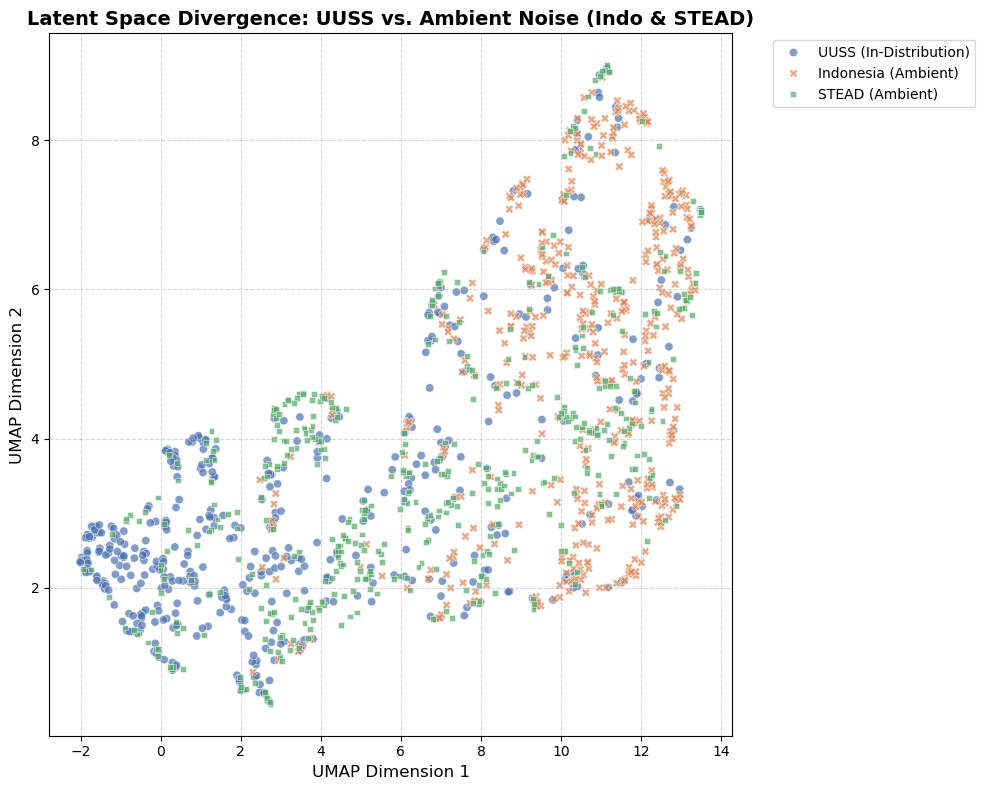

In [21]:
# -*- coding: utf-8 -*-
import os
import glob
import json
import h5py
import numpy as np
import pandas as pd
import umap
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow import keras

# ==============================================================================
# CONFIGURATION
# ==============================================================================
BASE_PATH = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying'
OUTPUT_DIR = os.path.join(BASE_PATH, 'figures_disertasi')
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Path Paths

MODEL_PATH = os.path.join(BASE_PATH, 'indonesia_jaya_benchmarking_data/mcquake_ori_file/Code & Figure demo/Pre-trained model/MCU-Quake 5-20')

UUSS_JSON = r'/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Benchmark_ UUSS 3C_ test n2222 r100/UUSS 3C data, test n2222 r100.json'
DIR_NOISE_INDO = r"/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/indonesia_waveform_master_data/output_data_npypure_3c_noise_9s"
PATH_STEAD_CSV = '/Volumes/Extreme SSD/stream_stead/data_stead/merge.csv'
PATH_STEAD_HDF5 = '/Volumes/Extreme SSD/stream_stead/data_stead/merge.hdf5'

# ==============================================================================
# FUNCTIONS
# ==============================================================================
def zhi_geng_normalize(waves):
    max_val = np.max(np.abs(waves))
    return waves / (max_val if max_val != 0 else 1e-8)

def get_embeddings(model, data_waves):
    # Memastikan input (N, 700, 3) diproses dengan benar
    return np.hstack([
        model.predict(data_waves[:, :, 0:1], verbose=0),
        model.predict(data_waves[:, :, 1:2], verbose=0),
        model.predict(data_waves[:, :, 2:3], verbose=0)
    ])

# ==============================================================================
# MAIN PIPELINE
# ==============================================================================
model = keras.models.load_model(MODEL_PATH, compile=False)
noise_collection = {}

# 1. Collect Data
print("[INFO] Mengumpulkan data 3-Domain...")
# UUSS
with open(UUSS_JSON, 'r') as f: uuss_data = json.load(f)
uuss_samples = [zhi_geng_normalize(np.stack([uuss_data[k]["E"], uuss_data[k]["N"], uuss_data[k]["Z"]], axis=-1)[:700]) 
                for k in list(uuss_data.keys())[:500]]
noise_collection['UUSS (In-Distribution)'] = np.array(uuss_samples)

# Indonesia
files = glob.glob(os.path.join(DIR_NOISE_INDO, "*.npy"))
raw_indo = np.array([zhi_geng_normalize(np.load(f)[:700]) for f in np.random.choice(files, 500, replace=False)])
noise_collection['Indonesia (Ambient)'] = raw_indo

# STEAD
df = pd.read_csv(PATH_STEAD_CSV, low_memory=False)
traces = df[df['trace_category'] == 'noise'].sample(500)['trace_name'].values
with h5py.File(PATH_STEAD_HDF5, 'r') as f:
    raw_stead = np.array([zhi_geng_normalize(f['data'][t][()][:700]) for t in traces if t in f['data']])
    noise_collection['STEAD (Ambient)'] = raw_stead

# 2. Extract & Embed
print("[INFO] Mengekstraksi fitur laten...")
X_list, labels = [], []
for domain, waves in noise_collection.items():
    X_list.append(get_embeddings(model, waves))
    labels.extend([domain] * len(waves))

# 3. UMAP Reduction
print("[INFO] Running UMAP Analysis...")
reducer = umap.UMAP(n_neighbors=20, min_dist=0.1, n_components=2, random_state=42)
embedding_2d = reducer.fit_transform(np.vstack(X_list))

# 4. Visualization (Publication Ready)
plt.figure(figsize=(10, 8))
sns.scatterplot(x=embedding_2d[:, 0], y=embedding_2d[:, 1], hue=labels, style=labels, palette="deep", alpha=0.7)
plt.title("Latent Space Divergence: UUSS vs. Ambient Noise (Indo & STEAD)", fontsize=14, weight='bold')
plt.xlabel("UMAP Dimension 1", fontsize=12)
plt.ylabel("UMAP Dimension 2", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Save output
plot_path = os.path.join(OUTPUT_DIR, "latent_space_divergence.png")
plt.savefig(plot_path, dpi=300)
print(f"[INFO] Plot tersimpan di: {plot_path}")
plt.show()

In [14]:
# -*- coding: utf-8 -*-
import os

uuss_json_path = r'/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Benchmark_ UUSS 3C_ test n2222 r100/UUSS 3C data, test n2222 r100.json'
print(f"[DEBUG] Mengecek keberadaan file: {uuss_json_path}")

if os.path.exists(uuss_json_path):
    print("[SUCCESS] File ditemukan!")
else:
    print("[ERROR] File tidak ditemukan di path tersebut.")
    
    # Memeriksa folder induknya
    parent_dir = os.path.dirname(uuss_json_path)
    print(f"[DEBUG] Mengecek folder induk: {parent_dir}")
    
    if os.path.exists(parent_dir):
        print(f"[INFO] Folder induk ada. Isi folder adalah: {os.listdir(parent_dir)}")
    else:
        print("[CRITICAL] Folder induk juga tidak ditemukan. Mohon cek kembali struktur folder di finder.")

[DEBUG] Mengecek keberadaan file: /Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Benchmark_ UUSS 3C_ test n2222 r100/UUSS 3C data, test n2222 r100.json
[SUCCESS] File ditemukan!


[INFO] Mengumpulkan data 3-Domain (Semua adalah Noise)...
[INFO] Mengumpulkan data UUSS Noise dengan sinkronisasi panjang...
[INFO] Berhasil memuat 500 sampel noise UUSS.


/opt/homebrew/Caskroom/miniforge/base/envs/mcu_quake_env/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


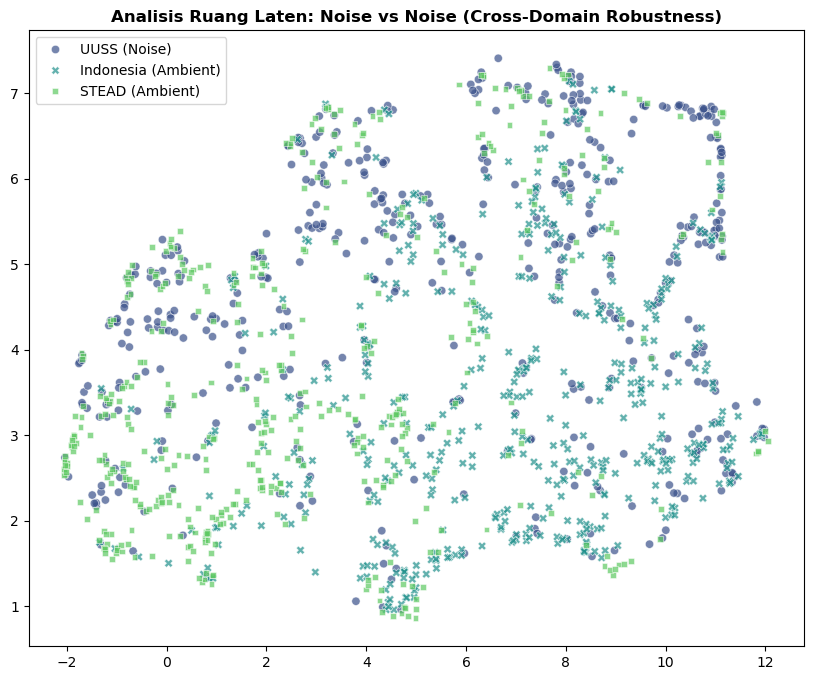

In [23]:
# -*- coding: utf-8 -*-
import os
import glob
import json
import h5py
import numpy as np
import pandas as pd
import umap
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow import keras

# ==============================================================================
# PATH & CONFIG
# ==============================================================================
# Pastikan path ini menunjuk ke file benchmark noise, bukan event
UUSS_JSON = r'/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Benchmark_ UUSS 3C_ test n2222 r100/UUSS 3C data, test n2222 r100.json'
DIR_NOISE_INDO = r"/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/indonesia_waveform_master_data/output_data_npypure_3c_noise_9s"
PATH_STEAD_CSV = '/Volumes/Extreme SSD/stream_stead/data_stead/merge.csv'
PATH_STEAD_HDF5 = '/Volumes/Extreme SSD/stream_stead/data_stead/merge.hdf5'
MODEL_PATH = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Code & Figure demo/Pre-trained model/MCU-Quake 5-20'

model = keras.models.load_model(MODEL_PATH, compile=False)

def zhi_geng_normalize(waves):
    max_val = np.max(np.abs(waves))
    return waves / (max_val if max_val != 0 else 1e-8)

def get_embeddings(model, data_waves):
    return np.hstack([
        model.predict(data_waves[:, :, 0:1], verbose=0),
        model.predict(data_waves[:, :, 1:2], verbose=0),
        model.predict(data_waves[:, :, 2:3], verbose=0)
    ])

# ==============================================================================
# DATA COLLECTION: NOISE vs NOISE vs NOISE
# ==============================================================================
print("[INFO] Mengumpulkan data 3-Domain (Semua adalah Noise)...")
noise_collection = {}

# 1. UUSS Noise
with open(UUSS_JSON, 'r') as f: uuss_data = json.load(f)
uuss_samples = []
print("[INFO] Mengumpulkan data UUSS Noise dengan sinkronisasi panjang...")
uuss_samples = []

for k in list(uuss_data.keys())[:500]:
    if "E_noise" in uuss_data[k]:
        # Konversi ke numpy array terlebih dahulu agar bisa di-slice
        e = np.array(uuss_data[k]["E_noise"])
        n = np.array(uuss_data[k]["N_noise"])
        z = np.array(uuss_data[k]["Z_noise"])
        
        # Ambil 700 sampel terakhir (atau sesuai panjang yang disepakati)
        # Slicing [-700:] akan mengambil 700 sampel terakhir. 
        # Jika data kurang dari 700, ini akan mengambil semua (perlu pengecekan)
        e = e[-700:]
        n = n[-700:]
        z = z[-700:]
        
        # Validasi: Pastikan ketiganya memiliki bentuk yang sama persis
        if e.shape == n.shape == z.shape and e.shape[0] == 700:
            wave = np.stack([e, n, z], axis=-1)
            uuss_samples.append(zhi_geng_normalize(wave))
        else:
            # Lewati jika data tidak konsisten atau kurang dari 700
            continue

noise_collection['UUSS (Noise)'] = np.array(uuss_samples)
print(f"[INFO] Berhasil memuat {len(uuss_samples)} sampel noise UUSS.")

# 2. Indonesia (Sudah Noise)
files = glob.glob(os.path.join(DIR_NOISE_INDO, "*.npy"))
raw_indo = np.array([zhi_geng_normalize(np.load(f)[:700]) for f in np.random.choice(files, 500, replace=False)])
noise_collection['Indonesia (Ambient)'] = raw_indo

# 3. STEAD Noise
df = pd.read_csv(PATH_STEAD_CSV, low_memory=False)
traces = df[df['trace_category'] == 'noise'].sample(500)['trace_name'].values
with h5py.File(PATH_STEAD_HDF5, 'r') as f:
    raw_stead = np.array([zhi_geng_normalize(f['data'][t][()][:700]) for t in traces if t in f['data']])
    noise_collection['STEAD (Ambient)'] = raw_stead

# ==============================================================================
# UMAP & PLOT
# ==============================================================================
X_list, labels = [], []
for domain, waves in noise_collection.items():
    X_list.append(get_embeddings(model, waves))
    labels.extend([domain] * len(waves))

reducer = umap.UMAP(n_neighbors=20, min_dist=0.1, n_components=2, random_state=42)
embedding_2d = reducer.fit_transform(np.vstack(X_list))

plt.figure(figsize=(10, 8))
sns.scatterplot(x=embedding_2d[:, 0], y=embedding_2d[:, 1], hue=labels, style=labels, palette="viridis", alpha=0.7)
plt.title("Analisis Ruang Laten: Noise vs Noise (Cross-Domain Robustness)", weight='bold')
plt.show()

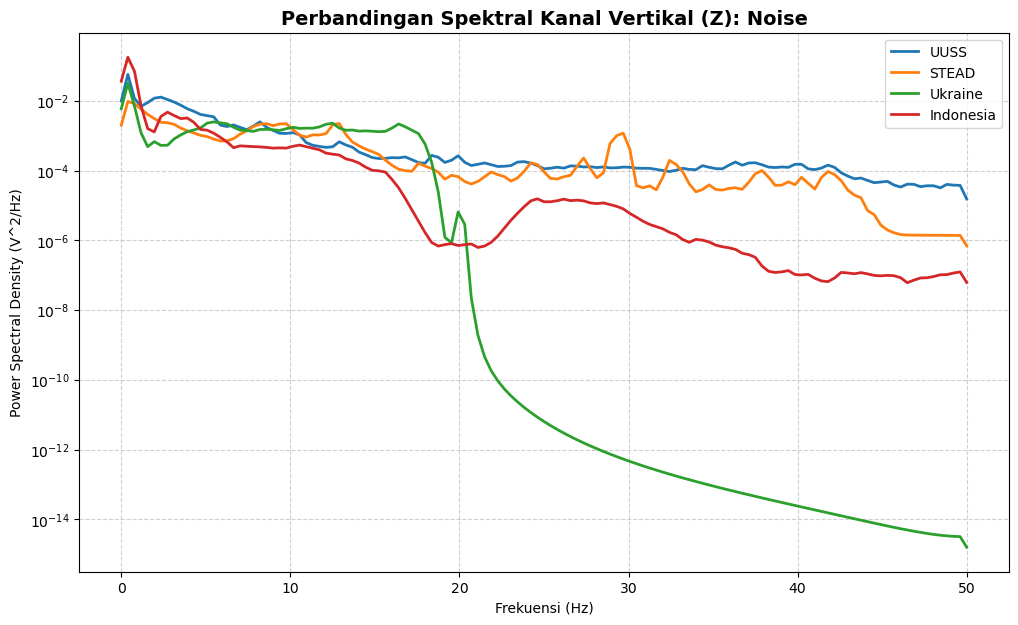

In [28]:
# -*- coding: utf-8 -*-
import json
import numpy as np
import glob
import os
from scipy.signal import welch
import matplotlib.pyplot as plt

# ==============================================================================
# CONFIGURATION
# ==============================================================================
DATA_MAP = {
    "UUSS": r'/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Benchmark_ UUSS 3C_ test n2222 r100/UUSS 3C data, test n2222 r100.json',
    "STEAD": '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Benchmark_ STEAD 3C_ test n15275 r100/STEAD data, test n15275 r100.json',
    "Ukraine": '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Benchmark_ Ukraine 3C_ test n1335 r100 sdb8-956/Ukraine data, test n1335 r100 sdb8-956.json'
}
DIR_NOISE_INDO = r"/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/indonesia_waveform_master_data/output_data_npypure_3c_noise_9s"

def zhi_geng_normalize(wave):
    max_val = np.max(np.abs(wave))
    return wave / (max_val if max_val != 0 else 1e-8)

def load_json_noise_z(path):
    with open(path, 'r') as f:
        data = json.load(f)
    samples = []
    keys = list(data.keys())
    suffix = "_noise" if "Z_noise" in data[keys[0]] else ""
    
    for k in keys[:300]: 
        try:
            # Ambil hanya kanal Z
            z = np.array(data[k][f"Z{suffix}"])
            if z.shape[0] >= 700:
                samples.append(zhi_geng_normalize(z[-700:]))
        except KeyError:
            continue
    return np.array(samples)

def load_indo_noise_z(dir_path):
    files = glob.glob(os.path.join(dir_path, "*.npy"))
    selected_files = np.random.choice(files, min(300, len(files)), replace=False)
    # Ambil index 2 (Z) dari file .npy yang bentuknya (700, 3)
    samples = [zhi_geng_normalize(np.load(f)[-700:, 2]) for f in selected_files]
    return np.array(samples)

# ==============================================================================
# ANALISIS SPEKTRAL Z-CHANNEL
# ==============================================================================
all_noise_data = {}
for name, path in DATA_MAP.items():
    all_noise_data[name] = load_json_noise_z(path)
all_noise_data["Indonesia"] = load_indo_noise_z(DIR_NOISE_INDO)

plt.figure(figsize=(12, 7))
for name, waves in all_noise_data.items():
    all_psd = []
    for wave in waves:
        f, psd = welch(wave, fs=100, nperseg=256)
        all_psd.append(psd)
    plt.semilogy(f, np.mean(all_psd, axis=0), label=name, linewidth=2)

plt.title("Perbandingan Spektral Kanal Vertikal (Z): Noise", weight='bold', fontsize=14)
plt.xlabel("Frekuensi (Hz)")
plt.ylabel("Power Spectral Density (V^2/Hz)")
plt.legend()
plt.grid(True, which="both", linestyle='--', alpha=0.6)
plt.show()

[INFO] Memproses STEAD Large Dataset dari HDF5...


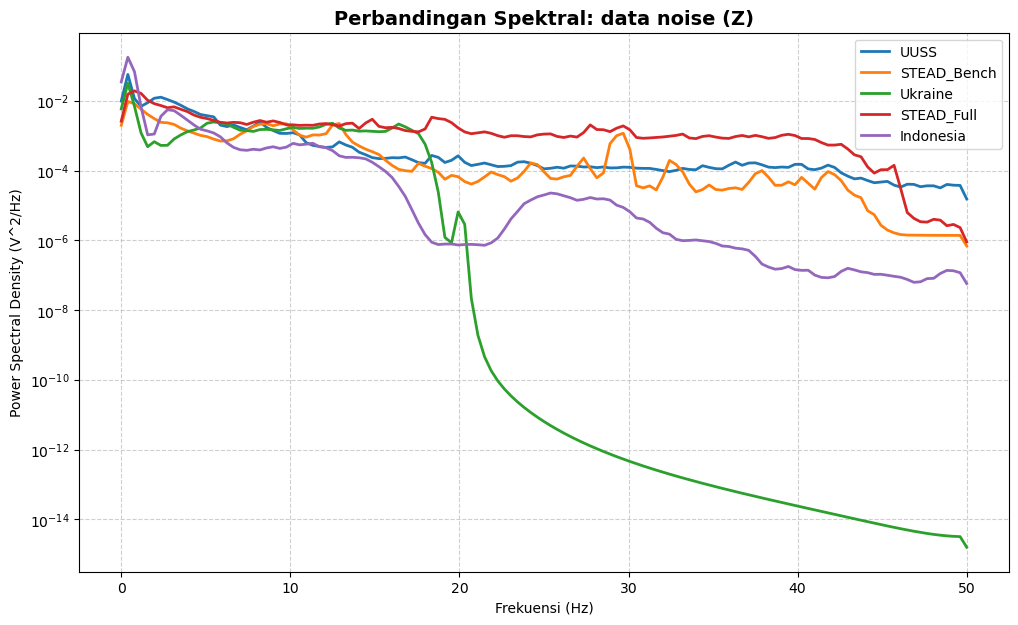

In [30]:
# -*- coding: utf-8 -*-
import json
import numpy as np
import glob
import os
import h5py
import pandas as pd
from scipy.signal import welch
import matplotlib.pyplot as plt

# ==============================================================================
# CONFIGURATION
# ==============================================================================
DATA_MAP = {
    "UUSS": r'/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Benchmark_ UUSS 3C_ test n2222 r100/UUSS 3C data, test n2222 r100.json',
    "STEAD_Bench": '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Benchmark_ STEAD 3C_ test n15275 r100/STEAD data, test n15275 r100.json',
    "Ukraine": '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Benchmark_ Ukraine 3C_ test n1335 r100 sdb8-956/Ukraine data, test n1335 r100 sdb8-956.json'
}

# Path Data Baru
STEAD_CSV = '/Volumes/Extreme SSD/stream_stead/data_stead/merge.csv'
STEAD_HDF5 = '/Volumes/Extreme SSD/stream_stead/data_stead/merge.hdf5'

DIR_NOISE_INDO = r"/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/indonesia_waveform_master_data/output_data_npypure_3c_noise_9s"

def zhi_geng_normalize(wave):
    max_val = np.max(np.abs(wave))
    return wave / (max_val if max_val != 0 else 1e-8)

# Fungsi untuk membaca JSON benchmark yang sudah ada
def load_json_noise_z(path):
    with open(path, 'r') as f:
        data = json.load(f)
    samples = []
    keys = list(data.keys())
    suffix = "_noise" if "Z_noise" in data[keys[0]] else ""
    for k in keys[:300]: 
        try:
            z = np.array(data[k][f"Z{suffix}"])
            if z.shape[0] >= 700:
                samples.append(zhi_geng_normalize(z[-700:]))
        except KeyError: continue
    return np.array(samples)

# FUNGSI BARU: Membaca dari HDF5 & CSV STEAD
def load_stead_large_noise_z(csv_path, h5_path, n_samples=300):
    print(f"[INFO] Memproses STEAD Large Dataset dari HDF5...")
    df = pd.read_csv(csv_path, usecols=['trace_name', 'trace_category'])
    noise_names = df[df['trace_category'] == 'noise']['trace_name'].sample(n=n_samples, random_state=42)
    
    samples = []
    with h5py.File(h5_path, 'r') as f:
        data_group = f['data']
        for name in noise_names:
            if name in data_group:
                wave = data_group[name][()] # Format biasanya (samples, 3)
                # Ambil kanal Z (indeks 2)
                z = wave[-700:, 2]
                samples.append(zhi_geng_normalize(z))
    return np.array(samples)

def load_indo_noise_z(dir_path):
    files = glob.glob(os.path.join(dir_path, "*.npy"))
    selected_files = np.random.choice(files, min(300, len(files)), replace=False)
    samples = [zhi_geng_normalize(np.load(f)[-700:, 2]) for f in selected_files]
    return np.array(samples)

# ==============================================================================
# EKSEKUSI ANALISIS
# ==============================================================================
all_noise_data = {}

# 1. Load semua benchmark JSON
for name, path in DATA_MAP.items():
    all_noise_data[name] = load_json_noise_z(path)

# 2. Load STEAD Besar (HDF5+CSV)
all_noise_data["STEAD_Full"] = load_stead_large_noise_z(STEAD_CSV, STEAD_HDF5)

# 3. Load Indonesia
all_noise_data["Indonesia"] = load_indo_noise_z(DIR_NOISE_INDO)

# Plotting
plt.figure(figsize=(12, 7))
for name, waves in all_noise_data.items():
    all_psd = []
    for wave in waves:
        f, psd = welch(wave, fs=100, nperseg=256)
        all_psd.append(psd)
    plt.semilogy(f, np.mean(all_psd, axis=0), label=name, linewidth=2)

plt.title("Perbandingan Spektral: data noise (Z)", weight='bold', fontsize=14)
plt.xlabel("Frekuensi (Hz)")
plt.ylabel("Power Spectral Density (V^2/Hz)")
plt.legend()
plt.grid(True, which="both", linestyle='--', alpha=0.6)
plt.show()

In [ ]:
# -*- coding: utf-8 -*-
import json
import numpy as np
import glob
import os
import h5py
import pandas as pd
import tensorflow as tf
import seaborn as sns
import matplotlib.pyplot as plt

# ==============================================================================
# 1. CONFIGURATION & PATHS
# ==============================================================================
MODEL_PATH = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Code & Figure demo/Pre-trained model/MCU-Quake 5-20'

DATA_MAP = {
    "UUSS": r'/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Benchmark_ UUSS 3C_ test n2222 r100/UUSS 3C data, test n2222 r100.json',
    "STEAD_Bench": '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Benchmark_ STEAD 3C_ test n15275 r100/STEAD data, test n15275 r100.json',
    "Ukraine": '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Benchmark_ Ukraine 3C_ test n1335 r100 sdb8-956/Ukraine data, test n1335 r100 sdb8-956.json'
}

STEAD_CSV = '/Volumes/Extreme SSD/stream_stead/data_stead/merge.csv'
STEAD_HDF5 = '/Volumes/Extreme SSD/stream_stead/data_stead/merge.hdf5'

DIR_NOISE_INDO = r"/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/indonesia_waveform_master_data/output_data_npypure_3c_noise_9s"

# ==============================================================================
# 2. DATA LOADING & PREPROCESSING
# ==============================================================================
def zhi_geng_normalize(wave):
    max_val = np.max(np.abs(wave))
    return wave / (max_val if max_val != 0 else 1e-8)

def load_json_noise_z(path):
    with open(path, 'r') as f:
        data = json.load(f)
    samples = []
    keys = list(data.keys())
    suffix = "_noise" if "Z_noise" in data[keys[0]] else ""
    for k in keys[:300]: 
        try:
            z = np.array(data[k][f"Z{suffix}"])
            if z.shape[0] >= 700:
                samples.append(zhi_geng_normalize(z[-700:]))
        except KeyError: continue
    return np.array(samples)

def load_stead_large_noise_z(csv_path, h5_path, n_samples=300):
    print("[INFO] Memuat sampel dari STEAD 1.2M (HDF5)...")
    df = pd.read_csv(csv_path, usecols=['trace_name', 'trace_category'])
    noise_names = df[df['trace_category'] == 'noise']['trace_name'].sample(n=n_samples, random_state=42)
    
    samples = []
    with h5py.File(h5_path, 'r') as f:
        data_group = f['data']
        for name in noise_names:
            if name in data_group:
                wave = data_group[name][()] 
                z = wave[-700:, 2] # Ambil kanal Z
                samples.append(zhi_geng_normalize(z))
    return np.array(samples)

def load_indo_noise_z(dir_path):
    print("[INFO] Memuat sampel Noise Indonesia...")
    files = glob.glob(os.path.join(dir_path, "*.npy"))
    selected_files = np.random.choice(files, min(300, len(files)), replace=False)
    samples = [zhi_geng_normalize(np.load(f)[-700:, 2]) for f in selected_files]
    return np.array(samples)

# Kumpulkan semua data
all_noise_data = {}
for name, path in DATA_MAP.items():
    print(f"[INFO] Memuat {name} dari JSON...")
    all_noise_data[name] = load_json_noise_z(path)

all_noise_data["STEAD_Full"] = load_stead_large_noise_z(STEAD_CSV, STEAD_HDF5)
all_noise_data["Indonesia"] = load_indo_noise_z(DIR_NOISE_INDO)

# ==============================================================================
# 3. TENSORFLOW INFERENCE
# ==============================================================================
def get_official_embeddings(model_folder, data_dict):
    print(f"\n[INFO] Memuat TensorFlow SavedModel dari: {model_folder}")
    model = tf.saved_model.load(model_folder)
    infer = model.signatures["serving_default"]
    
    latent_results = {}
    
    for domain, waves in data_dict.items():
        # Format input MCU-Quake: [Batch, Length, Channel] -> [N, 700, 1]
        data_tensor = tf.convert_to_tensor(waves.reshape(-1, 700, 1), dtype=tf.float32)
        
        outputs = infer(data_tensor)
        
        # Ekstrak nilai output dari key pertama yang tersedia
        output_key = list(outputs.keys())[0]
        latent_codes = outputs[output_key].numpy().flatten()
        
        latent_results[domain] = latent_codes
        print(f"[SUCCESS] Ekstraksi embedding untuk {domain} selesai. (Total: {len(latent_codes)})")
        
    return latent_results

latent_results = get_official_embeddings(MODEL_PATH, all_noise_data)

# ==============================================================================
# 4. VISUALISASI RUANG LATEN
# ==============================================================================
plt.figure(figsize=(12, 7))
for domain, codes in latent_results.items():
    sns.kdeplot(codes, label=domain, fill=True, alpha=0.3, linewidth=2)

# Garis referensi "Knowledge Center" untuk noise berdasarkan paper Zhi Geng 
plt.axvline(x=-5.01, color='red', linestyle='--', linewidth=2, label='Knowledge Center (Noise = -5.01)')

plt.title("Perbandingan Distribusi Ruang Laten (TensorFlow Official Model)", weight='bold', fontsize=14)
plt.xlabel("Latent Code Value (Embedding)", fontsize=12)
plt.ylabel("Likelihood (Density)", fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

[INFO] Memuat UUSS dari JSON...
[INFO] Memuat STEAD_Bench dari JSON...
[INFO] Memuat Ukraine dari JSON...
[INFO] Memuat sampel dari STEAD 1.2M (HDF5)...
[INFO] Memuat sampel Noise Indonesia...

[INFO] Memuat TensorFlow SavedModel dari: /Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/MCU-Quake 5-20


OSError: SavedModel file does not exist at: /Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/MCU-Quake 5-20/{saved_model.pbtxt|saved_model.pb}